>
---
Pakages import

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split
from imblearn.over_sampling import SMOTE
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.metrics import classification_report, ConfusionMatrixDisplay
from sklearn.inspection import permutation_importance
import joblib

# Load data
df = pd.read_csv('../data/ml_raw_data/healthcare-dataset-stroke-data.csv')
df = df.drop('id', axis=1) # ID is useless for ML

# Fix Missing BMI
df['bmi'] = df['bmi'].fillna(df['bmi'].median())

# Check
print(df.isnull().sum())
print(df.head())

gender               0
age                  0
hypertension         0
heart_disease        0
ever_married         0
work_type            0
Residence_type       0
avg_glucose_level    0
bmi                  0
smoking_status       0
stroke               0
dtype: int64
   gender   age  hypertension  heart_disease ever_married      work_type  \
0    Male  67.0             0              1          Yes        Private   
1  Female  61.0             0              0          Yes  Self-employed   
2    Male  80.0             0              1          Yes        Private   
3  Female  49.0             0              0          Yes        Private   
4  Female  79.0             1              0          Yes  Self-employed   

  Residence_type  avg_glucose_level   bmi   smoking_status  stroke  
0          Urban             228.69  36.6  formerly smoked       1  
1          Rural             202.21  28.1     never smoked       1  
2          Rural             105.92  32.5     never smoked       1  
3

>
---
Stroke Distribution

C:\Users\user\AppData\Local\Temp\ipykernel_5792\1656192073.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='stroke', data=df, palette='pastel')


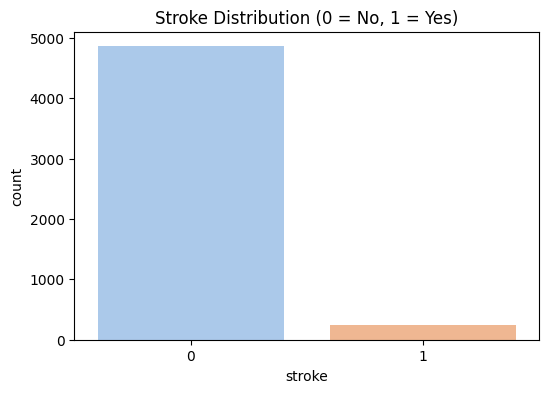

In [2]:
# How many people had a stroke vs who didn't
plt.figure(figsize=(6,4))
sns.countplot(x='stroke', data=df, palette='pastel')
plt.title('Stroke Distribution (0 = No, 1 = Yes)')
plt.show()

>
---
Data splitting & scaling & encoding & balancing

In [ ]:

# Simple Encoding for binary/simple columns
le = LabelEncoder()
df['gender'] = le.fit_transform(df['gender'])
df['ever_married'] = le.fit_transform(df['ever_married'])
df['Residence_type'] = le.fit_transform(df['Residence_type'])

# One-Hot Encoding for categories with many options (creates new columns)
df = pd.get_dummies(df, columns=['work_type', 'smoking_status'])

print("Data Encoded! New shape:", df.shape)
print(df.head())

# Create a feature that combines known medical risks
# This is a simple way to capture the combined effect of age, hypertension, and heart disease on stroke risk.
df['medical_risk_factor'] = df['age'] * (df['hypertension'] + df['heart_disease'] + 1)

# Define Features and Target
X = df.drop('stroke', axis=1)
y = df['stroke']

# 2. Split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# 3. Scale
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# 4. Balance with SMOTE
smote = SMOTE(random_state=42)
X_train_balanced, y_train_balanced = smote.fit_resample(X_train_scaled, y_train)

print(f"Original class counts: {y_train.value_counts().to_dict()}")
print(f"Balanced class counts: {pd.Series(y_train_balanced).value_counts().to_dict()}")

Data Encoded! New shape: (5110, 18)
   gender   age  hypertension  heart_disease  ever_married  Residence_type  \
0       1  67.0             0              1             1               1   
1       0  61.0             0              0             1               0   
2       1  80.0             0              1             1               0   
3       0  49.0             0              0             1               1   
4       0  79.0             1              0             1               0   

   avg_glucose_level   bmi  stroke  work_type_Govt_job  \
0             228.69  36.6       1               False   
1             202.21  28.1       1               False   
2             105.92  32.5       1               False   
3             171.23  34.4       1               False   
4             174.12  24.0       1               False   

   work_type_Never_worked  work_type_Private  work_type_Self-employed  \
0                   False               True                    False   


>
---
The correlation heatmap

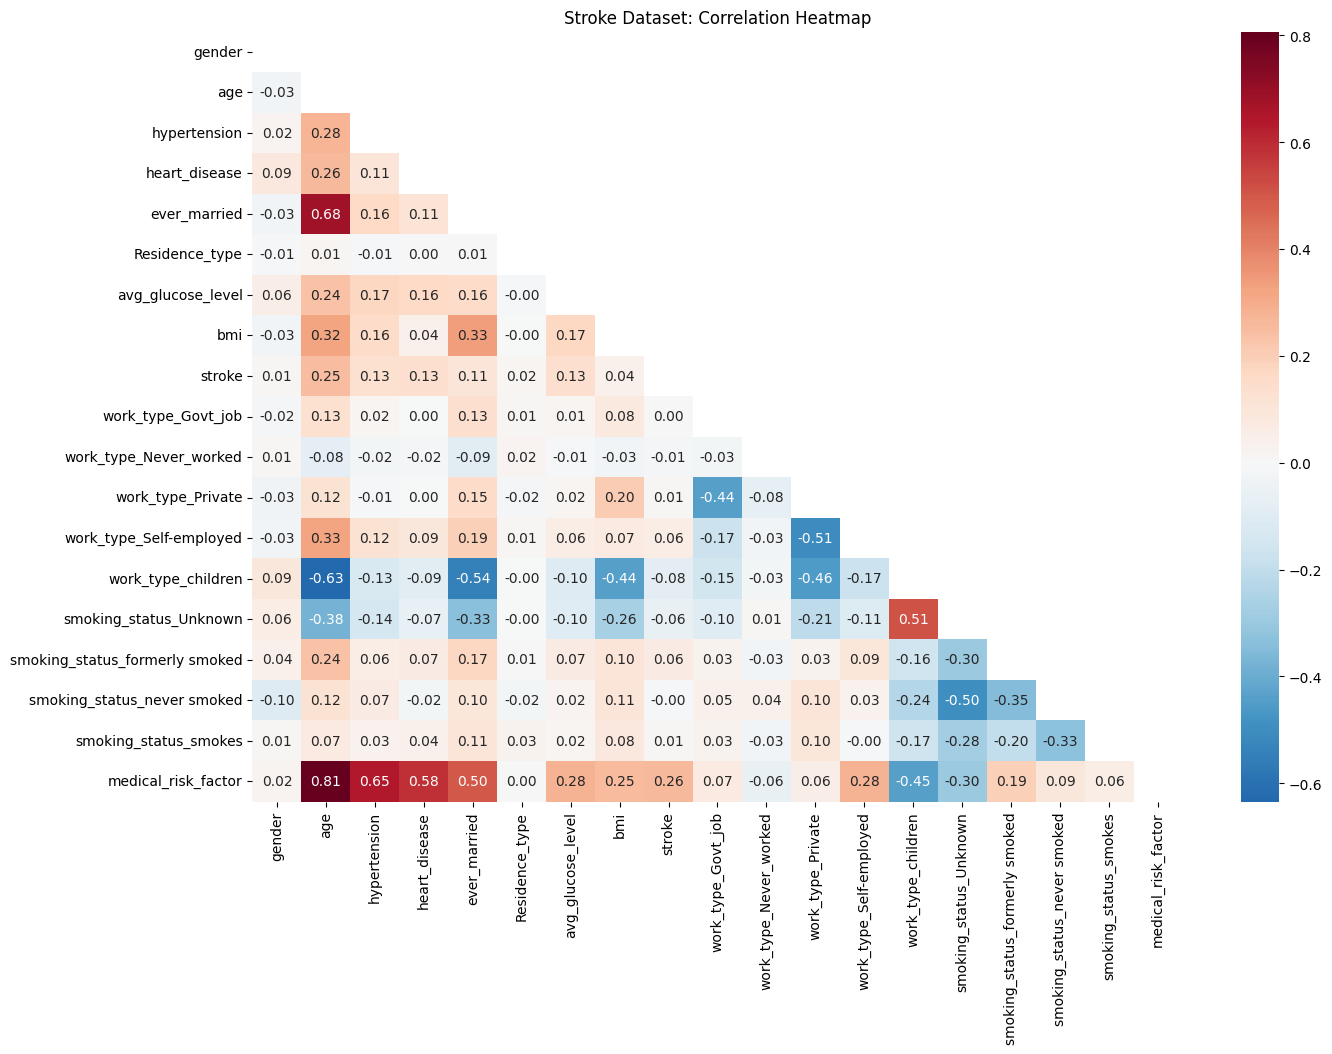

In [4]:
plt.figure(figsize=(15, 10))
# Using a mask to only show the bottom triangle makes it much easier to read
mask = np.triu(np.ones_like(df.corr(), dtype=bool))
sns.heatmap(df.corr(), mask=mask, annot=True, fmt='.2f', cmap='RdBu_r', center=0)
plt.title('Stroke Dataset: Correlation Heatmap')
plt.show()

>
---
Model training & Evaluation


================ Random Forest (Threshold: 0.55) ================
              precision    recall  f1-score   support

   No Stroke       0.96      0.97      0.96       972
      Stroke       0.16      0.12      0.14        50

    accuracy                           0.93      1022
   macro avg       0.56      0.54      0.55      1022
weighted avg       0.92      0.93      0.92      1022



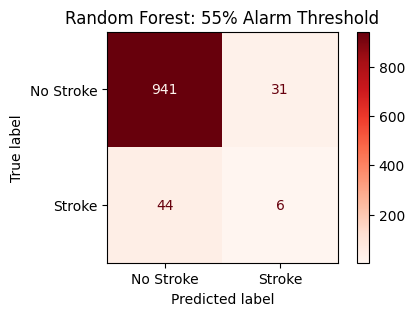


================ Logistic Regression (Threshold: 0.55) ================
              precision    recall  f1-score   support

   No Stroke       0.99      0.77      0.87       972
      Stroke       0.15      0.80      0.26        50

    accuracy                           0.77      1022
   macro avg       0.57      0.79      0.56      1022
weighted avg       0.95      0.77      0.84      1022



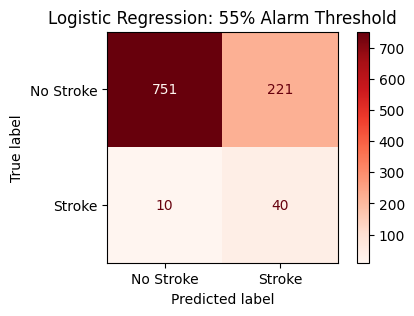


================ SVM (Threshold: 0.55) ================
              precision    recall  f1-score   support

   No Stroke       0.97      0.88      0.92       972
      Stroke       0.17      0.48      0.25        50

    accuracy                           0.86      1022
   macro avg       0.57      0.68      0.58      1022
weighted avg       0.93      0.86      0.89      1022



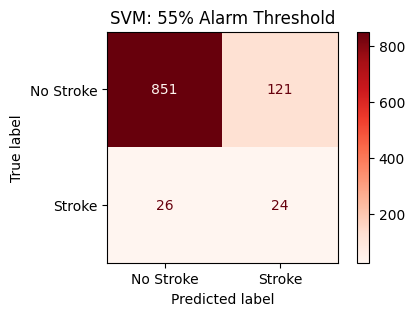

In [5]:

models = {
    "Random Forest": RandomForestClassifier(n_estimators=100, random_state=42),
    "Logistic Regression": LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42),
    "SVM": SVC(kernel='rbf', probability=True, random_state=42)
}

threshold = 0.55

# Training and Evaluation Loop
for name, model in models.items():
    model.fit(X_train_balanced, y_train_balanced)
    
    # Instead of a hard 0 or 1, we get the % chance of stroke
    probs = model.predict_proba(X_test_scaled)[:, 1]

    # If the model is at least 55% sure, we call it a 'Stroke'
    custom_preds = (probs >= threshold).astype(int)

    print(f"\n================ {name} (Threshold: {threshold}) ================")
    print(classification_report(y_test, custom_preds, target_names=['No Stroke', 'Stroke']))
    
    # Confusion Matrix Plotting
    fig, ax = plt.subplots(figsize=(5, 3))
    ConfusionMatrixDisplay.from_predictions(y_test, custom_preds, 
                                            display_labels=['No Stroke', 'Stroke'], 
                                            cmap='Reds', ax=ax)
    plt.title(f'{name}: 55% Alarm Threshold')
    plt.show()

>
---
Feature Importance 

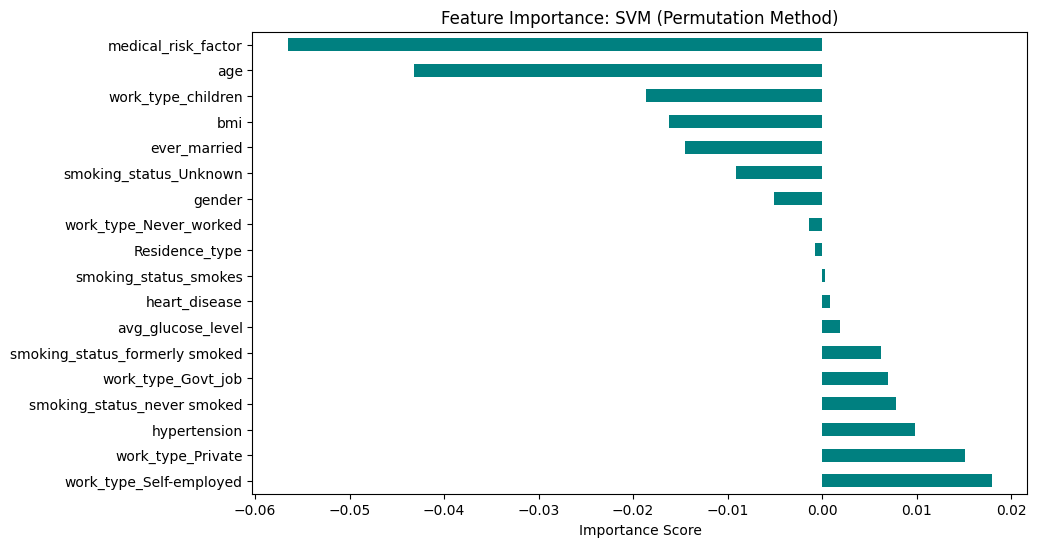

In [6]:
# Permutation Importance works by "shuffling" each column to see how much the model's performance drops. 
# If shuffling "Age" breaks the model, then "Age" is important.

# Calculate importance for SVM model
result = permutation_importance(models['SVM'], X_test_scaled, y_test, n_repeats=10, random_state=42)

# Organize into a Series
feat_importances = pd.Series(result.importances_mean, index=X.columns).sort_values(ascending=False)

# Plotting
plt.figure(figsize=(10, 6))
feat_importances.plot(kind='barh', color='teal')
plt.title('Feature Importance: SVM (Permutation Method)')
plt.xlabel('Importance Score')
plt.show()

>
---
Saving the model and the scaler

In [7]:
joblib.dump(models['Logistic Regression'], '../models/stroke_model.pkl')
joblib.dump(scaler, '../models/stroke_scaler.pkl')
print("\nStroke Model & Scaler saved successfully!")


Stroke Model & Scaler saved successfully!


>
---
After looking at the feature importance plot :While Age is a classic medical predictor, my model is finding that Work Type is a massive driver for stroke risk in this specific dataset. certain work environments carry higher stress levels, which correlates with health outcomes.